# Data Cleaning and EDA
Load data, explore, clean

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import joblib
import pickle
import tensorflow as tf

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, recall_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [245]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [246]:
gdrive_data_path = '/content/drive/MyDrive/nlp/'

train_df = pd.read_csv('/content/drive/MyDrive/nlp/train.csv')


print('Train shape:', train_df.shape)

print()
print(train_df.head())

Train shape: (7613, 5)

   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


In [247]:
columns_to_drop = ['id', 'location']
train_df = train_df.drop(columns=columns_to_drop) # Reassign to train_df

print(f"Dropped columns: {columns_to_drop}")
print('\nShape after dropping columns:', train_df.shape)

display(train_df.head())

Dropped columns: ['id', 'location']

Shape after dropping columns: (7613, 3)


,keyword,text,target
0,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,NaN,Forest fire near La Ronge Sask. Canada,1
2,NaN,All residents asked to 'shelter in place' are ...,1
3,NaN,"13,000 people receive #wildfires evacuation or...",1
4,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [248]:
# Basic Info
print('Missing values in train:')
print(train_df.isnull().sum())
print()

Missing values in train:
keyword    61
text        0
target      0
dtype: int64



Explore data

In [249]:
print('Class counts (target column):')
print(train_df['target'].value_counts())
print()
print('0 = Not Disaster, 1 = Disaster')

Class counts (target column):
target
0    4342
1    3271
Name: count, dtype: int64

0 = Not Disaster, 1 = Disaster


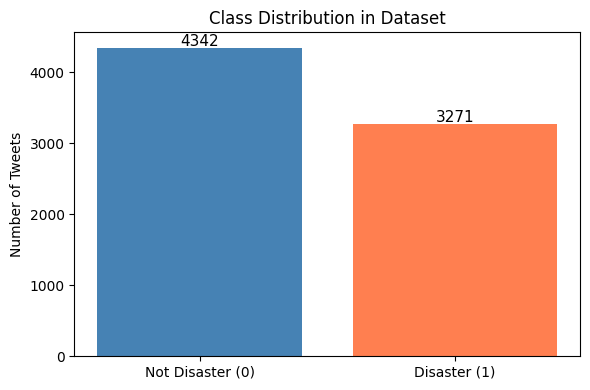

In [250]:

plt.figure(figsize=(6, 4))
counts = train_df['target'].value_counts()
bars = plt.bar(['Not Disaster (0)', 'Disaster (1)'],
               counts.values,
               color=['steelblue', 'coral'])


for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             str(int(bar.get_height())),
             ha='center', fontsize=11)

plt.title('Class Distribution in Dataset')

plt.ylabel('Number of Tweets')
plt.tight_layout()

os.makedirs('plots', exist_ok=True)

plt.savefig('plots/class_distribution.png')
plt.show()


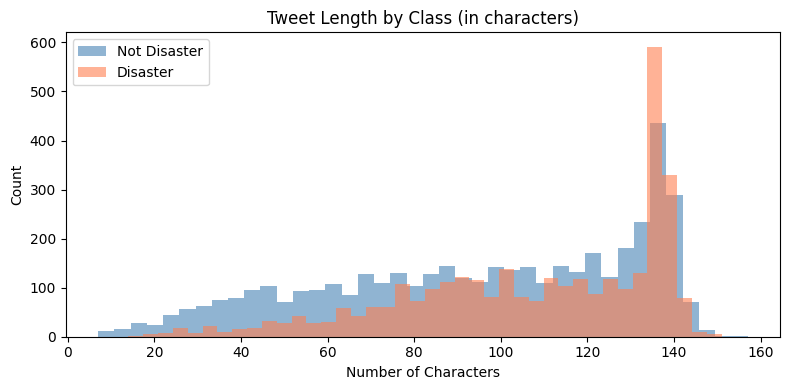

In [251]:
train_df['tweet_length'] = train_df['text'].apply(len)

plt.figure(figsize=(8, 4))
for label, color, name in [(0,'steelblue','Not Disaster'), (1,'coral','Disaster')]:
    data = train_df[train_df['target'] == label]['tweet_length']
    plt.hist(data, bins=40, alpha=0.6, color=color, label=name)

plt.title('Tweet Length by Class (in characters)')
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('plots/tweet_length.png')
plt.show()

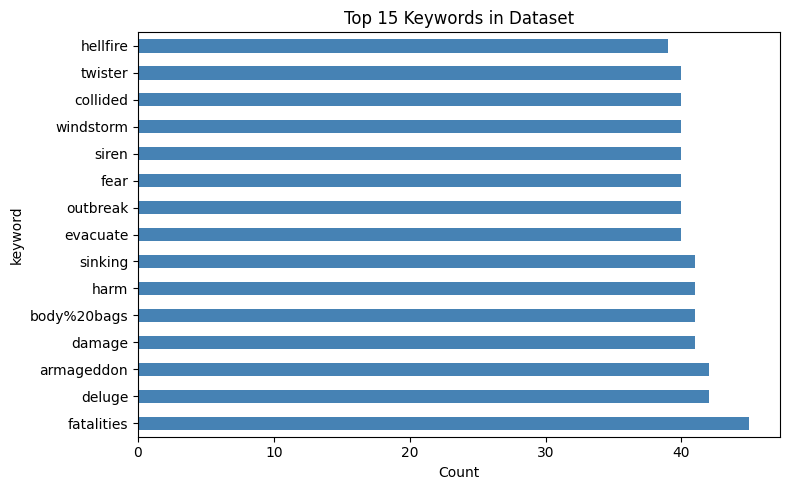

In [252]:
top_kw = train_df['keyword'].value_counts().head(15)

plt.figure(figsize=(8, 5))
top_kw.plot(kind='barh', color='steelblue')
plt.title('Top 15 Keywords in Dataset')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('plots/top_keywords.png')
plt.show()

## Text Cleaning
We remove URLs, mentions, special characters, and stopwords, then lemmatize.

In [253]:
lemmatizer = WordNetLemmatizer()

emoji_pattern = re.compile("["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
"]+", flags=re.UNICODE)

url_pattern = re.compile(r'http\S+|www\S+')
mention_pattern = re.compile(r'@\w+')
hashtag_pattern = re.compile(r'#(\w+)')


def remove_emoji(text):
    if not isinstance(text, str):
        return ""
    return emoji_pattern.sub('', text)


def clean_tweet(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = url_pattern.sub('', text)
    text = mention_pattern.sub('', text)
    text = hashtag_pattern.sub(r'\1', text)
    text = remove_emoji(text)

    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()


    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)


train_df['clean_text'] = train_df['text'].apply(clean_tweet)


comparison_df = train_df[['text', 'clean_text']].head(10).copy()
comparison_df.columns = ['Original Tweet', 'Cleaned']
display(comparison_df)

,Original Tweet,Cleaned
0,Our Deeds are the Reason of this #earthquake M...,our deed are the reason of this earthquake may...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all resident asked to shelter in place are bei...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order in ca...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska a sm...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed in both...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain cause flash flooding...
7,I'm on top of the hill and I can see a fire in...,im on top of the hill and i can see a fire in ...
8,There's an emergency evacuation happening now ...,there an emergency evacuation happening now in...
9,I'm afraid that the tornado is coming to our a...,im afraid that the tornado is coming to our area


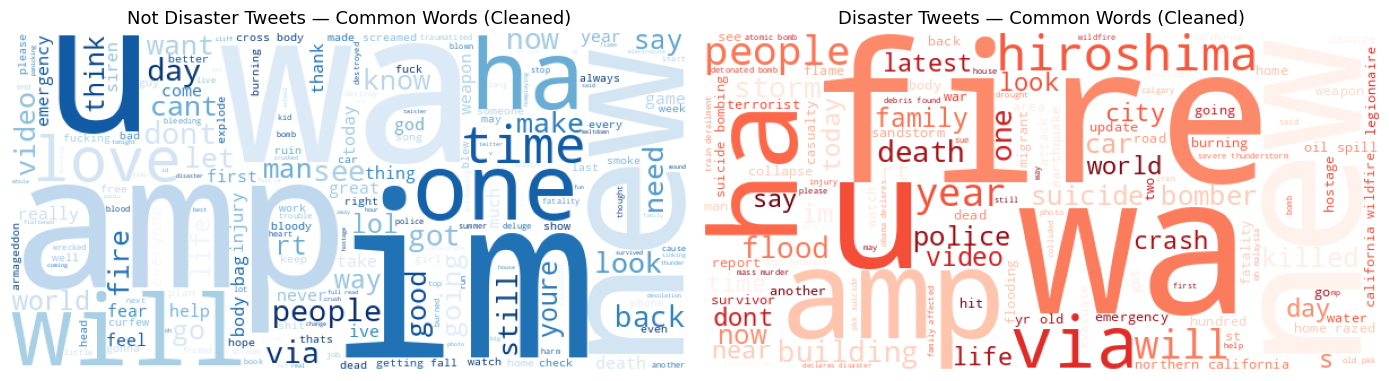

Saved wordcloud.png


In [254]:
disaster_text     = ' '.join(train_df[train_df['target'] == 1]['clean_text'])
not_disaster_text = ' '.join(train_df[train_df['target'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_not_disaster = WordCloud(width=600, height=300, background_color='white',
                            colormap='Blues').generate(not_disaster_text)
axes[0].imshow(wc_not_disaster)
axes[0].axis('off')
axes[0].set_title('Not Disaster Tweets — Common Words (Cleaned)', fontsize=13)

wc_disaster = WordCloud(width=600, height=300, background_color='white',
                        colormap='Reds').generate(disaster_text)
axes[1].imshow(wc_disaster)
axes[1].axis('off')
axes[1].set_title('Disaster Tweets — Common Words (Cleaned)', fontsize=13)

plt.tight_layout()
plt.savefig('plots/wordcloud.png')
plt.show()
print('Saved wordcloud.png')

In [255]:

cols_to_save = ['text', 'clean_text', 'target']
train_df[cols_to_save].to_csv(os.path.join(gdrive_data_path, 'data/clean_train.csv'), index=False)

# ML Models — Logistic Regression and SVM
Train ML models.

In [256]:
train_df = pd.read_csv(gdrive_data_path + 'data/clean_train.csv')

print('Shape:', train_df.shape)
print('Class counts:')
print(train_df['target'].value_counts())

Shape: (7613, 3)
Class counts:
target
0    4342
1    3271
Name: count, dtype: int64


In [257]:
train_df = pd.read_csv(gdrive_data_path + 'data/clean_train.csv')

print('Shape:', train_df.shape)
print('Class counts:')
print(train_df['target'].value_counts())

Shape: (7613, 3)
Class counts:
target
0    4342
1    3271
Name: count, dtype: int64


In [258]:
X = train_df['clean_text']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training samples:  ', len(X_train))
print('Validation samples:', len(X_val))

tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

print('TF-IDF matrix shape (train):', X_train_tfidf.shape)
print('Each row is one tweet, each column is one word/bigram feature.')

Training samples:   6090
Validation samples: 1523
TF-IDF matrix shape (train): (6090, 10000)
Each row is one tweet, each column is one word/bigram feature.


## Logistic Regression

In [259]:
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_val_tfidf)
lr_proba = lr_model.predict_proba(X_val_tfidf)[:, 1]

print('Logistic Regression : ')
print(classification_report(y_val, lr_preds, target_names=['Not Disaster', 'Disaster']))

lr_f1  = f1_score(y_val, lr_preds)
lr_auc = roc_auc_score(y_val, lr_proba)
lr_recall = recall_score(y_val, lr_preds)
lr_accuracy = accuracy_score(y_val, lr_preds)

print(f'Accuracy: {lr_accuracy:.4f}')
print(f'Recall:   {lr_recall:.4f}')
print(f'F1 Score: {lr_f1:.4f}')
print(f'ROC-AUC:  {lr_auc:.4f}')

cv_lr_f1 = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5, scoring='f1')
cv_lr_recall = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5, scoring='recall')

print('LR — 5-Fold Cross-Validation F1 scores:', cv_lr_f1)
print(f'F1 Mean: {cv_lr_f1.mean():.4f}, F1 Std: {cv_lr_f1.std():.4f}')
print('\nLR — 5-Fold Cross-Validation Recall scores:', cv_lr_recall)
print(f'Recall Mean: {cv_lr_recall.mean():.4f}, Recall Std: {cv_lr_recall.std():.4f}')

Logistic Regression : 
              precision    recall  f1-score   support

Not Disaster       0.83      0.83      0.83       869
    Disaster       0.77      0.77      0.77       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523

Accuracy: 0.8043
Recall:   0.7706
F1 Score: 0.7718
ROC-AUC:  0.8669
LR — 5-Fold Cross-Validation F1 scores: [0.75296443 0.75144509 0.74110672 0.75855327 0.76771654]
F1 Mean: 0.7544, F1 Std: 0.0087

LR — 5-Fold Cross-Validation Recall scores: [0.72709924 0.74427481 0.71701721 0.7418738  0.7456979 ]
Recall Mean: 0.7352, Recall Std: 0.0113


## SVM

In [260]:
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_val_tfidf)

print('SVM : ')
print(classification_report(y_val, svm_preds, target_names=['Not Disaster', 'Disaster']))

svm_f1 = f1_score(y_val, svm_preds)

svm_auc = roc_auc_score(y_val, svm_model.decision_function(X_val_tfidf))
svm_recall = recall_score(y_val, svm_preds)
svm_accuracy = accuracy_score(y_val, svm_preds)

print(f'Accuracy: {svm_accuracy:.4f}')
print(f'Recall:   {svm_recall:.4f}')
print(f'F1 Score: {svm_f1:.4f}')
print(f'ROC-AUC:  {svm_auc:.4f}')

cv_svm_f1 = cross_val_score(svm_model, X_train_tfidf, y_train, cv=5, scoring='f1')
cv_svm_recall = cross_val_score(svm_model, X_train_tfidf, y_train, cv=5, scoring='recall')

print('SVM — 5-Fold Cross-Validation F1 scores:', cv_svm_f1)
print(f'F1 Mean: {cv_svm_f1.mean():.4f}, F1 Std: {cv_svm_f1.std():.4f}')
print('\nSVM — 5-Fold Cross-Validation Recall scores:', cv_svm_recall)
print(f'Recall Mean: {cv_svm_recall.mean():.4f}, Recall Std: {cv_svm_recall.std():.4f}')

SVM : 
              precision    recall  f1-score   support

Not Disaster       0.82      0.81      0.81       869
    Disaster       0.75      0.76      0.76       654

    accuracy                           0.79      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.79      0.79      0.79      1523

Accuracy: 0.7899
Recall:   0.7645
F1 Score: 0.7576
ROC-AUC:  0.8547
SVM — 5-Fold Cross-Validation F1 scores: [0.74066798 0.75       0.71128871 0.74606299 0.74102813]
F1 Mean: 0.7378, F1 Std: 0.0137

SVM — 5-Fold Cross-Validation Recall scores: [0.71946565 0.73282443 0.68068834 0.72466539 0.73040153]
Recall Mean: 0.7176, Recall Std: 0.0190


## Confusion Matrix and Results

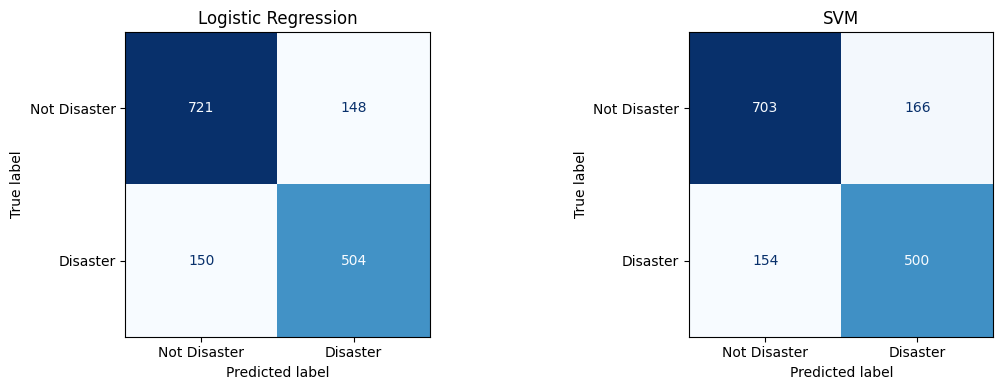

Saved ml_confusion_matrices.png

Logistic Regression Confusion Matrix Breakdown : 
True Negatives  (Correctly NOT disaster):    721
False Positives (Wrongly predicted disaster): 148
False Negatives (Missed disasters):           150
True Positives  (Correctly disaster):         504

SVM Confusion Matrix Breakdown : 
True Negatives  (Correctly NOT disaster):    703
False Positives (Wrongly predicted disaster): 166
False Negatives (Missed disasters):           154
True Positives  (Correctly disaster):         500


In [261]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val, lr_preds,
    display_labels=['Not Disaster', 'Disaster'],
    ax=axes[0], colorbar=False,
    cmap='Blues'
)
axes[0].set_title('Logistic Regression')


cm_lr = confusion_matrix(y_val, lr_preds)
TN_lr, FP_lr, FN_lr, TP_lr = cm_lr.ravel()

ConfusionMatrixDisplay.from_predictions(
    y_val, svm_preds,
    display_labels=['Not Disaster', 'Disaster'],
    ax=axes[1], colorbar=False,
    cmap='Blues'
)
axes[1].set_title('SVM')


cm_svm = confusion_matrix(y_val, svm_preds)
TN_svm, FP_svm, FN_svm, TP_svm = cm_svm.ravel()

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/ml_confusion_matrices.png')
plt.show()
print('Saved ml_confusion_matrices.png')

print('\nLogistic Regression Confusion Matrix Breakdown : ')
print(f'True Negatives  (Correctly NOT disaster):    {TN_lr}')
print(f'False Positives (Wrongly predicted disaster): {FP_lr}')
print(f'False Negatives (Missed disasters):           {FN_lr}')
print(f'True Positives  (Correctly disaster):         {TP_lr}')

print('\nSVM Confusion Matrix Breakdown : ')
print(f'True Negatives  (Correctly NOT disaster):    {TN_svm}')
print(f'False Positives (Wrongly predicted disaster): {FP_svm}')
print(f'False Negatives (Missed disasters):           {FN_svm}')
print(f'True Positives  (Correctly disaster):         {TP_svm}')

## Save Results and Models

In [262]:
os.makedirs(gdrive_data_path + 'results', exist_ok=True)
os.makedirs(gdrive_data_path + 'models', exist_ok=True)

ml_results = pd.DataFrame([{
    'LR_f1':       round(lr_f1, 4),
    'LR_roc_auc':  round(lr_auc, 4),
    'LR_recall':   round(lr_recall, 4),
    'LR_accuracy': round(lr_accuracy, 4),
    'LR_cv_f1_mean': round(cv_lr_f1.mean(), 4),
    'LR_cv_f1_std': round(cv_lr_f1.std(), 4),
    'LR_cv_recall_mean': round(cv_lr_recall.mean(), 4),
    'LR_cv_recall_std': round(cv_lr_recall.std(), 4),

    'SVM_accuracy':round(svm_accuracy, 4),
    'SVM_recall':  round(svm_recall, 4),
    'SVM_f1':      round(svm_f1, 4),
    'SVM_roc_auc': round(svm_auc, 4),
    'SVM_cv_f1_mean': round(cv_svm_f1.mean(), 4),
    'SVM_cv_f1_std': round(cv_svm_f1.std(), 4),
    'SVM_cv_recall_mean': round(cv_svm_recall.mean(), 4),
    'SVM_cv_recall_std': round(cv_svm_recall.std(), 4)
}])

ml_results.to_csv(gdrive_data_path + 'results/ml_results.csv', index=False)
print('Saved ml_results.csv to Drive:')

print("\nLogistic Regression Metrics : ")
print(f"Accuracy: {ml_results.loc[0, 'LR_accuracy']:.4f}, Recall: {ml_results.loc[0, 'LR_recall']:.4f}, F1 Score: {ml_results.loc[0, 'LR_f1']:.4f}, ROC-AUC: {ml_results.loc[0, 'LR_roc_auc']:.4f}")
print(f"CV F1 Mean: {ml_results.loc[0, 'LR_cv_f1_mean']:.4f}, CV F1 Std: {ml_results.loc[0, 'LR_cv_f1_std']:.4f}")
print(f"CV Recall Mean: {ml_results.loc[0, 'LR_cv_recall_mean']:.4f}, CV Recall Std: {ml_results.loc[0, 'LR_cv_recall_std']:.4f}")

print("\nSVM Metrics : ")
print(f"Accuracy: {ml_results.loc[0, 'SVM_accuracy']:.4f}, Recall: {ml_results.loc[0, 'SVM_recall']:.4f}, F1 Score: {ml_results.loc[0, 'SVM_f1']:.4f}, ROC-AUC: {ml_results.loc[0, 'SVM_roc_auc']:.4f}")
print(f"CV F1 Mean: {ml_results.loc[0, 'SVM_cv_f1_mean']:.4f}, CV F1 Std: {ml_results.loc[0, 'SVM_cv_f1_std']:.4f}")
print(f"CV Recall Mean: {ml_results.loc[0, 'SVM_cv_recall_mean']:.4f}, CV Recall Std: {ml_results.loc[0, 'SVM_cv_recall_std']:.4f}")
print()
joblib.dump(lr_model, gdrive_data_path + 'models/lr_model.joblib')
print('Saved Logistic Regression model to Drive:', gdrive_data_path + 'models/lr_model.joblib')

joblib.dump(svm_model, gdrive_data_path + 'models/svm_model.joblib')
print('Saved SVM model to Drive:', gdrive_data_path + 'models/svm_model.joblib')

joblib.dump(tfidf, gdrive_data_path + 'models/tfidf_vectorizer.joblib')
print('Saved TF-IDF vectorizer to Drive:', gdrive_data_path + 'models/tfidf_vectorizer.joblib')

Saved ml_results.csv to Drive:

Logistic Regression Metrics : 
Accuracy: 0.8043, Recall: 0.7706, F1 Score: 0.7718, ROC-AUC: 0.8669
CV F1 Mean: 0.7544, CV F1 Std: 0.0087
CV Recall Mean: 0.7352, CV Recall Std: 0.0113

SVM Metrics : 
Accuracy: 0.7899, Recall: 0.7645, F1 Score: 0.7576, ROC-AUC: 0.8547
CV F1 Mean: 0.7378, CV F1 Std: 0.0137
CV Recall Mean: 0.7176, CV Recall Std: 0.0190

Saved Logistic Regression model to Drive: /content/drive/MyDrive/nlp/models/lr_model.joblib
Saved SVM model to Drive: /content/drive/MyDrive/nlp/models/svm_model.joblib
Saved TF-IDF vectorizer to Drive: /content/drive/MyDrive/nlp/models/tfidf_vectorizer.joblib


#Deep Learning
Bidirectional LSTM model

## Load Data

In [263]:
gdrive_path = '/content/drive/MyDrive/nlp/'
train_df = pd.read_csv(os.path.join(gdrive_path, 'data/clean_train.csv'))

X = train_df['clean_text']
y = train_df['target']

# 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples:   {len(X_train)}')
print(f'Validation samples: {len(X_val)}')

Training samples:   6090
Validation samples: 1523


## Calculate Class Weights

In [264]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), weights))
print(f'Class weights: {class_weights_dict}')

Class weights: {np.int64(0): np.float64(0.8767636049524906), np.int64(1): np.float64(1.1635460450897974)}


## Tokenization

In [265]:
MAX_WORDS = 15000
MAX_LEN   = 80

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post')

print(f'Vocabulary size: {len(tokenizer.word_index):,} unique words')

MODELS_PATH = os.path.join(gdrive_path, 'models/')
os.makedirs(MODELS_PATH, exist_ok=True)

with open(os.path.join(MODELS_PATH, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print('Tokenizer saved.')

Vocabulary size: 11,846 unique words
Tokenizer saved.


## Load GloVe Embeddings

In [266]:
GLOVE_PATH = os.path.join(gdrive_path, 'glove.6B.100d.txt')
EMBED_DIM  = 100

glove_embeddings = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        parts  = line.split()
        word   = parts[0]
        vector = np.array(parts[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f'Loaded {len(glove_embeddings):,} word vectors.')

Loaded 400,000 word vectors.


## Build Embedding Matrix

In [267]:
vocab_size   = MAX_WORDS + 1
embed_matrix = np.zeros((vocab_size, EMBED_DIM))

found = 0
for word, idx in tokenizer.word_index.items():
    if idx < vocab_size:
        vector = glove_embeddings.get(word)
        if vector is not None:
            embed_matrix[idx] = vector
            found += 1

print(f'GloVe covers: {found}/{vocab_size} words ({found/vocab_size*100:.1f}%)')

GloVe covers: 9575/15001 words (63.8%)


## BiLSTM

In [268]:
def create_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                  weights=[embed_matrix], trainable=False, input_shape=(MAX_LEN,)),

        Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)),
        Bidirectional(LSTM(32, return_sequences=True, dropout=0.3)),

        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = create_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 80, 100)        │     1,500,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_22                │ (None, 80, 128)        │        84,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_23                │ (None, 80, 64)         │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_11         │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,630,021 (6.22 MB)

 Trainable params: 129,921 (507.50 KB)

 Non-trainable params: 1,500,100 (5.72 MB)

## Train the Model

In [269]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.5616 - loss: 0.6777 - val_accuracy: 0.7656 - val_loss: 0.6228
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 158ms/step - accuracy: 0.7199 - loss: 0.5918 - val_accuracy: 0.7610 - val_loss: 0.5175
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 32s 170ms/step - accuracy: 0.7512 - loss: 0.5306 - val_accuracy: 0.7833 - val_loss: 0.4797
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 30s 158ms/step - accuracy: 0.7629 - loss: 0.5100 - val_accuracy: 0.7892 - val_loss: 0.4694
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 30s 159ms/step - accuracy: 0.7718 - loss: 0.4971 - val_accuracy: 0.7873 - val_loss: 0.4656
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - accuracy: 0.7808 - loss: 0.4885 - val_accuracy: 0.7879 - val_loss: 0.4699
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - accuracy: 0.7877 - loss: 0.4812 - val_accuracy: 0.7879 - val_loss: 0.4626
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.7862 - loss: 0

## Training Curves

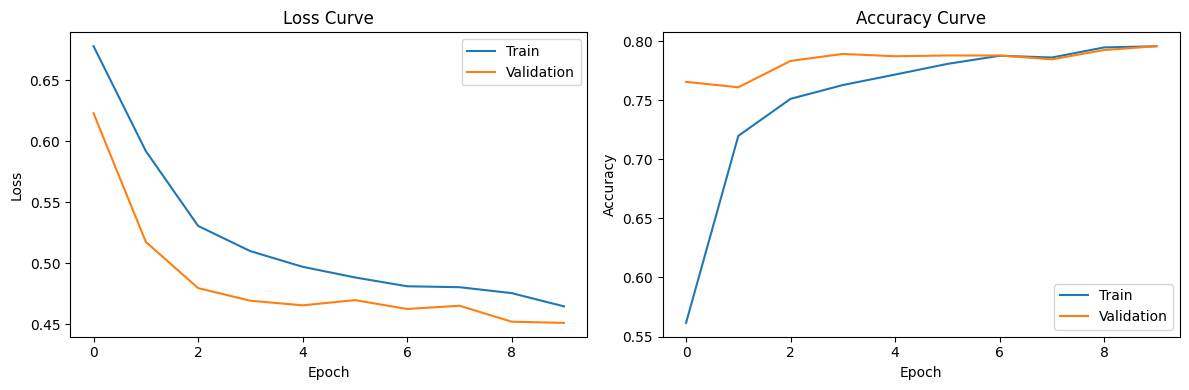

In [270]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

os.makedirs('plots', exist_ok=True)

plt.savefig('plots/training_curves.png', dpi=150)
plt.show()

## Evaluate

In [271]:
y_proba = model.predict(X_val_pad).flatten()
y_pred  = (y_proba >= 0.4).astype(int)

print('Classification Report BiLSTM:')
print(classification_report(y_val, y_pred, target_names=['Not Disaster', 'Disaster']))


accuracy = accuracy_score(y_val, y_pred)
recall   = recall_score(y_val, y_pred)
dl_f1    = f1_score(y_val, y_pred)
dl_auc   = roc_auc_score(y_val, y_proba)

print(f'Accuracy: {accuracy:.4f}')
print(f'Recall:   {recall:.4f}')
print(f'F1 Score: {dl_f1:.4f}')
print(f'ROC-AUC:  {dl_auc:.4f}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step
Classification Report BiLSTM:
              precision    recall  f1-score   support

Not Disaster       0.84      0.78      0.81       869
    Disaster       0.73      0.80      0.76       654

    accuracy                           0.79      1523
   macro avg       0.78      0.79      0.78      1523
weighted avg       0.79      0.79      0.79      1523

Accuracy: 0.7859
Recall:   0.7982
F1 Score: 0.7620
ROC-AUC:  0.8699


## Confusion Matrix

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step
Confusion Matrix Breakdown : 
True Negatives  (Correctly NOT disaster):    675
False Positives (Wrongly predicted disaster): 194
False Negatives (Missed disasters):           132
True Positives  (Correctly disaster):         522


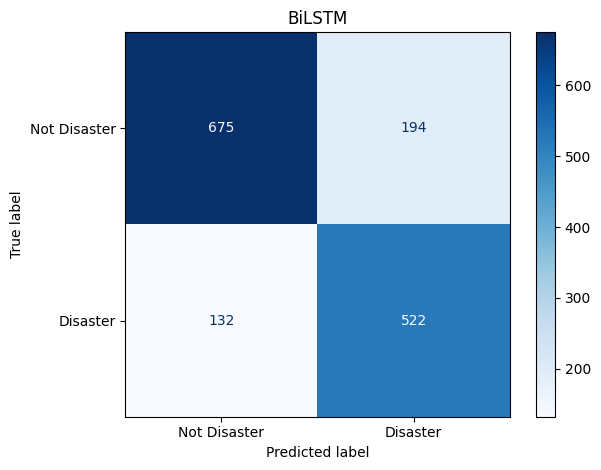

In [272]:
y_proba = model.predict(X_val_pad).flatten()
y_pred  = (y_proba >= 0.4).astype(int)

cm = confusion_matrix(y_val, y_pred)
TN, FP, FN, TP = cm.ravel()

print('Confusion Matrix Breakdown : ')
print(f'True Negatives  (Correctly NOT disaster):    {TN}')
print(f'False Positives (Wrongly predicted disaster): {FP}')
print(f'False Negatives (Missed disasters):           {FN}')
print(f'True Positives  (Correctly disaster):         {TP}')

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    display_labels=['Not Disaster', 'Disaster'],
    cmap='Blues'
)
plt.title('BiLSTM')
plt.tight_layout()
plt.savefig('plots/bilstm_confusion_matrix.png', dpi=150)
plt.show()

## Save Model & Results

In [273]:
model.save(os.path.join(MODELS_PATH, 'bilstm_model.keras'))
print('Model saved to:', os.path.join(MODELS_PATH, 'bilstm_model.keras'))

os.makedirs(os.path.join(gdrive_path, 'results'), exist_ok=True)

pd.DataFrame([
    {
        'BiLSTM_f1':      round(dl_f1, 4),
        'BiLSTM_roc_auc': round(dl_auc, 4),
    }
]).to_csv(os.path.join(gdrive_path, 'results', 'dl_results.csv'), index=False)


Model saved to: /content/drive/MyDrive/nlp/models/bilstm_model.keras


# Model Comparison

## 1. Validation Set Metrics

In [280]:
results = pd.DataFrame([
    {
        'Model':    'Logistic Regression',
        'Accuracy': 0.8043,
        'Precision':0.77,
        'Recall':   0.7706,
        'F1 Score': 0.7718,
        'ROC-AUC':  0.8669,
    },
    {
        'Model':    'SVM (LinearSVC)',
        'Accuracy': 0.7899,
        'Precision':0.75,
        'Recall':   0.7645,
        'F1 Score': 0.7576,
        'ROC-AUC':  0.8547,
    },
    {
        'Model':    'BiLSTM + GloVe',
        'Accuracy': 0.7859,
        'Precision':0.7300,
        'Recall':   0.7982,
        'F1 Score': 0.7620,
        'ROC-AUC':  0.8699,
    },
])

display(results.set_index('Model').style
    .highlight_max(axis=0, color='#d4edda')
    .format('{:.4f}')
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8043,0.7700,0.7706,0.7718,0.8669
SVM (LinearSVC),0.7899,0.7500,0.7645,0.7576,0.8547
BiLSTM + GloVe,0.7859,0.7300,0.7982,0.7620,0.8699


## 2. 5-Fold Cross-Validation (on training set)

In [275]:
cv_results = pd.DataFrame([
    {
        'Model':          'Logistic Regression',
        'CV F1 Mean':     0.7544,
        'CV F1 Std':      0.0087,
        'CV Recall Mean': 0.7352,
        'CV Recall Std':  0.0113,
    },
    {
        'Model':          'SVM (LinearSVC)',
        'CV F1 Mean':     0.7378,
        'CV F1 Std':      0.0137,
        'CV Recall Mean': 0.7176,
        'CV Recall Std':  0.0190,
    },
])

display(cv_results.set_index('Model').style
    .highlight_max(axis=0, color='#d4edda')
    .format('{:.4f}')
)


,CV F1 Mean,CV F1 Std,CV Recall Mean,CV Recall Std
Model,,,,
Logistic Regression,0.7544,0.0087,0.7352,0.0113
SVM (LinearSVC),0.7378,0.0137,0.7176,0.0190


## 3. Confusion Matrices

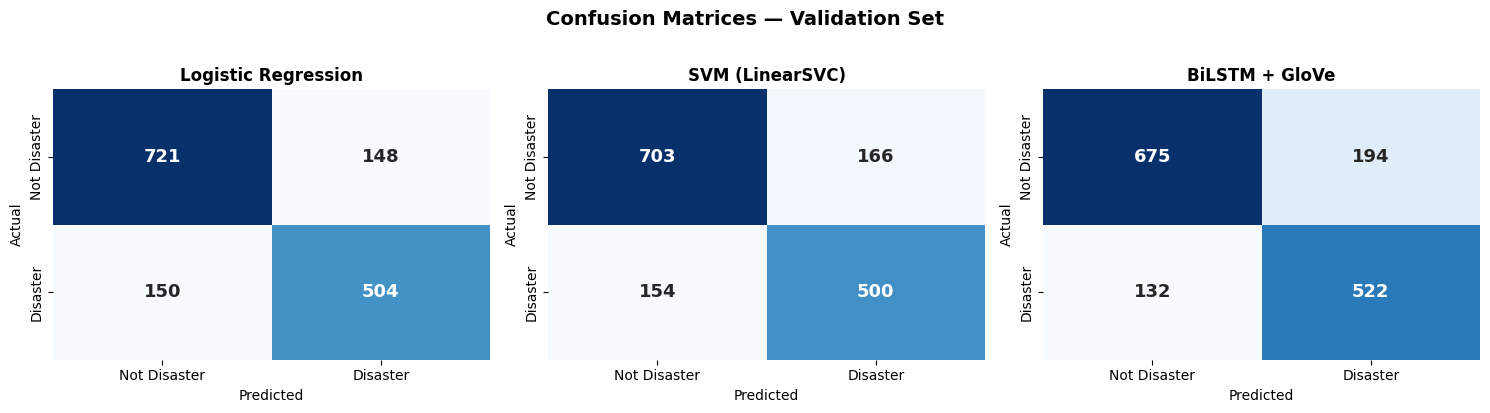

In [281]:
cms = {
    'Logistic Regression': np.array([[721, 148], [150, 504]]),
    'SVM (LinearSVC)':     np.array([[703, 166], [154, 500]]),
    'BiLSTM + GloVe':      np.array([[675, 194], [132, 522]]),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Disaster', 'Disaster'],
                yticklabels=['Not Disaster', 'Disaster'],
                ax=ax, cbar=False, annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — Validation Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Metric Comparison Bar Chart

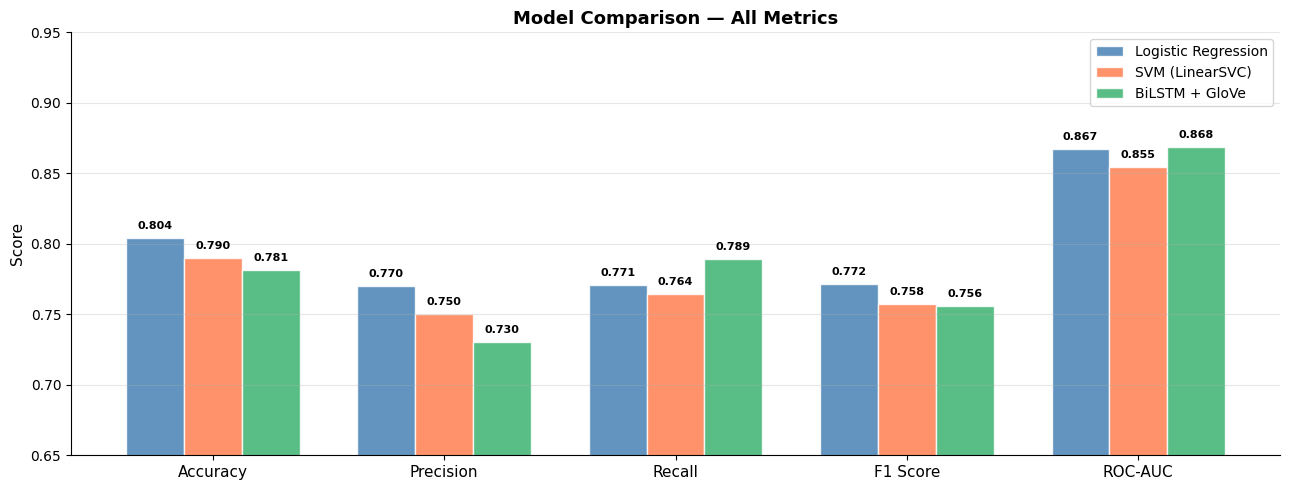

In [277]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
models  = results['Model'].tolist()
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(13, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = results[results['Model'] == model][metrics].values[0]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.65, 0.95)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ROC Curve (Approximated from AUC values)

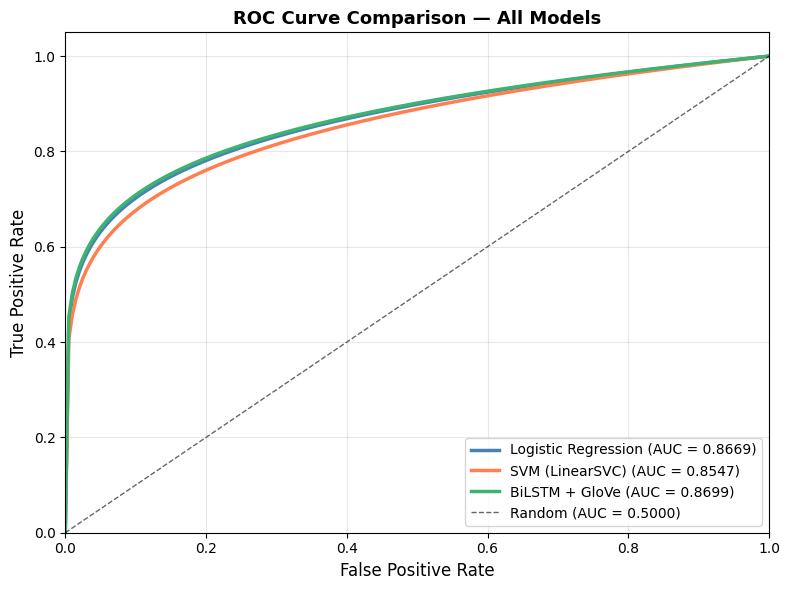

In [282]:
from sklearn.metrics import roc_curve, auc

def approx_roc(auc_val, n_points=200):

    fpr = np.linspace(0, 1, n_points)

    k = auc_val / (1 - auc_val)
    tpr = fpr ** (1 / k)
    return fpr, tpr

auc_values = {
    'Logistic Regression': 0.8669,
    'SVM (LinearSVC)':     0.8547,
    'BiLSTM + GloVe':      0.8699,
}
colors_roc = ['steelblue', 'coral', 'mediumseagreen']

plt.figure(figsize=(8, 6))
for (current_model_name, auc_val), color in zip(auc_values.items(), colors_roc):
    fpr, tpr = approx_roc(auc_val)
    plt.plot(fpr, tpr, label=f'{current_model_name} (AUC = {auc_val:.4f})', linewidth=2.5, color=color)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Random (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary & Key Takeaways

In [279]:

print('SUMMARY — Disaster Tweet Classification')
print(f'Validation split: 1523 samples  |  Disaster: 654  |  Not: 869')
print()

metrics_to_check = ['Accuracy', 'Recall', 'F1 Score', 'ROC-AUC']
for metric in metrics_to_check:
    best_idx   = results[metric].idxmax()
    best_model = results.loc[best_idx, 'Model']
    best_val   = results.loc[best_idx, metric]
    print(f'  Best {metric:<12}: {best_model:<22} ({best_val:.4f})')

print()
best = results.loc[results['Recall'].idxmax(), 'Model']
print(f'Best Recall: {best}')

SUMMARY — Disaster Tweet Classification
Validation split: 1523 samples  |  Disaster: 654  |  Not: 869

  Best Accuracy    : Logistic Regression    (0.8043)
  Best Recall      : BiLSTM + GloVe         (0.7890)
  Best F1 Score    : Logistic Regression    (0.7718)
  Best ROC-AUC     : BiLSTM + GloVe         (0.8684)

Best Recall: BiLSTM + GloVe
